In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erfc
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

Es/N0=-2dB -> SER=4.48898e-01
Es/N0=0dB -> SER=3.47402e-01
Es/N0=2dB -> SER=2.35962e-01
Es/N0=4dB -> SER=1.31528e-01
Es/N0=6dB -> SER=5.44280e-02
Es/N0=8dB -> SER=1.43240e-02
Es/N0=10dB -> SER=2.03600e-03
Es/N0=12dB -> SER=7.60000e-05
Es/N0=14dB -> SER=0.00000e+00
Es/N0=16dB -> SER=0.00000e+00
Es/N0=18dB -> SER=0.00000e+00
Es/N0=20dB -> SER=0.00000e+00


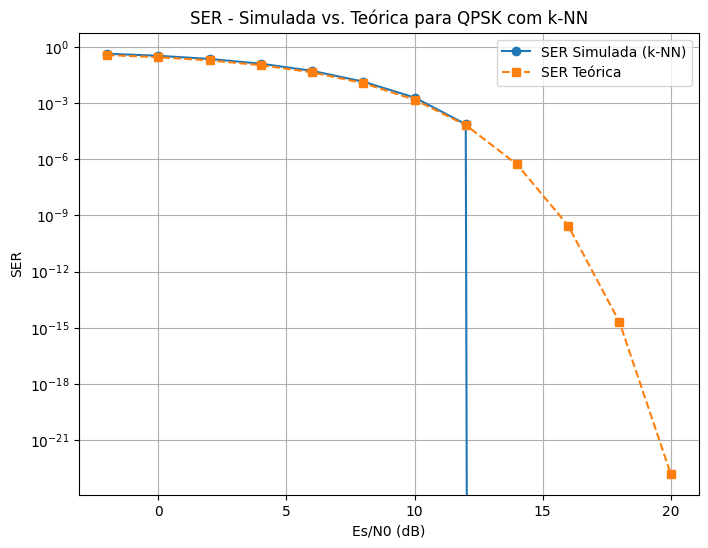

In [1]:

# Função da SER teórica para QPSK
def ser_theoretical_qpsk(esn0_linear):
    return erfc(np.sqrt(esn0_linear / 2)) - (1/4) * (erfc(np.sqrt(esn0_linear / 2)))**2


N = 1000000
esn0_dB = np.arange(-2, 22, 2)
esn0_linear = 10 ** (esn0_dB / 10)


bits = np.random.randint(0, 2, (N, 2))

mapping = {
    (0, 0): (1/np.sqrt(2), 1/np.sqrt(2)),
    (0, 1): (-1/np.sqrt(2), 1/np.sqrt(2)),
    (1, 0): (1/np.sqrt(2), -1/np.sqrt(2)),
    (1, 1): (-1/np.sqrt(2), -1/np.sqrt(2))
}

symbols = np.array([mapping[tuple(b)] for b in bits])
symbols_complex = symbols[:, 0] + 1j * symbols[:, 1]

ser_simulated = []


for esn0 in esn0_linear:
    # AWGN
    noise_std = np.sqrt(1/(2 * esn0))
    noise = noise_std * (np.random.randn(N) + 1j * np.random.randn(N))
    received = symbols_complex + noise

    X = np.column_stack((np.real(received), np.imag(received)))
    y = [tuple(b) for b in bits]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.5, random_state=42)


    knn = KNeighborsClassifier(n_neighbors=3)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)


    errors = np.sum(np.any(np.array(y_pred) != np.array(y_test), axis=1))
    ser = errors / len(y_test)
    ser_simulated.append(ser)

    print(f"Es/N0={10*np.log10(esn0):.0f}dB -> SER={ser:.5e}")

#  SER Teórica
ser_theory = ser_theoretical_qpsk(esn0_linear)

# Plot da SER
plt.figure(figsize=(8,6))
plt.semilogy(esn0_dB, ser_simulated, 'o-', label='SER Simulada (k-NN)')
plt.semilogy(esn0_dB, ser_theory, 's--', label='SER Teórica')
plt.xlabel('Es/N0 (dB)')
plt.ylabel('SER')
plt.title('SER - Simulada vs. Teórica para QPSK com k-NN')
plt.grid(True, which='both')
plt.legend()
plt.show()
